# 04. Model Analysis and Feature Importance

In the previous notebook, a baseline Logistic Regression model was built to predict 30-day hospital readmission.

This notebook focuses on understanding the model and identifying the factors most associated with readmission risk.

The goal is to make the project more interpretable and healthcare-focused by answering:

- Which features increase predicted readmission risk?
- Which features decrease predicted readmission risk?
- What patterns can be explained in a healthcare context?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

## Load Saved Model and Data

The baseline Logistic Regression pipeline was saved in the previous notebook.

The pipeline contains both preprocessing steps and the trained Logistic Regression model.

In [2]:
model_path = "../models/baseline_logistic_regression_pipeline.pkl"
data_path = "../data/processed/diabetic_data_preprocessed.csv"

baseline_model = joblib.load(model_path)
df = pd.read_csv(data_path)

df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,medical_specialty_grouped,readmitted_30_days
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,Other,0
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,Up,No,No,No,No,No,Ch,Yes,Unknown,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,Yes,Unknown,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,Up,No,No,No,No,No,Ch,Yes,Unknown,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,Steady,No,No,No,No,No,Ch,Yes,Unknown,0


In [3]:
df.shape

(101766, 44)

## Separate Features and Target

The target variable is removed from the feature matrix before analyzing the model.

In [4]:
X = df.drop(columns=["readmitted_30_days"])
y = df["readmitted_30_days"]

X.shape, y.shape

((101766, 43), (101766,))

## Access Pipeline Components

The saved pipeline contains two main parts:

- `preprocessor`: handles scaling and one-hot encoding
- `model`: trained Logistic Regression model

To interpret the model, we need the transformed feature names and their corresponding coefficients.

In [5]:
preprocessor = baseline_model.named_steps["preprocessor"]
log_reg_model = baseline_model.named_steps["model"]

## Extract Transformed Feature Names

After preprocessing, categorical variables are expanded into many one-hot encoded columns.

This step extracts the final feature names used by the Logistic Regression model.

In [6]:
feature_names = preprocessor.get_feature_names_out()

feature_names[:20]

array(['num__time_in_hospital', 'num__num_lab_procedures',
       'num__num_procedures', 'num__num_medications',
       'num__number_outpatient', 'num__number_emergency',
       'num__number_inpatient', 'num__number_diagnoses',
       'cat__race_AfricanAmerican', 'cat__race_Asian',
       'cat__race_Caucasian', 'cat__race_Hispanic', 'cat__race_Other',
       'cat__race_Unknown', 'cat__gender_Female', 'cat__gender_Male',
       'cat__gender_Unknown/Invalid', 'cat__age_[0-10)',
       'cat__age_[10-20)', 'cat__age_[20-30)'], dtype=object)

In [7]:
len(feature_names)

2327

## Extract Logistic Regression Coefficients

Logistic Regression assigns a coefficient to each transformed feature.

Positive coefficients indicate features associated with higher predicted readmission risk.

Negative coefficients indicate features associated with lower predicted readmission risk.

In [8]:
coefficients = log_reg_model.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df.head()

,feature,coefficient
0,num__time_in_hospital,-0.003567
1,num__num_lab_procedures,-0.011841
2,num__num_procedures,-0.014115
3,num__num_medications,0.034095
4,num__number_outpatient,-0.010868


## Clean Feature Names for Readability

The feature names are cleaned to make the tables and plots easier to understand.

In [9]:
coef_df["feature_clean"] = (
    coef_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

coef_df.head()

,feature,coefficient,feature_clean
0,num__time_in_hospital,-0.003567,time_in_hospital
1,num__num_lab_procedures,-0.011841,num_lab_procedures
2,num__num_procedures,-0.014115,num_procedures
3,num__num_medications,0.034095,num_medications
4,num__number_outpatient,-0.010868,number_outpatient


## Top Features Associated With Higher Readmission Risk

The following features have the largest positive coefficients.

These features increase the model's predicted probability of 30-day readmission.

In [10]:
top_positive = coef_df.sort_values(
    by="coefficient",
    ascending=False
).head(20)

top_positive[["feature_clean", "coefficient"]]

,feature_clean,coefficient
237,diag_1_356,2.138044
1833,diag_3_602,2.032086
2299,discharge_disposition_id_15,1.991064
731,diag_2_136,1.981785
1545,diag_3_250.91,1.953725
1461,diag_3_156,1.902100
466,diag_1_643,1.898132
468,diag_1_646,1.877677
2186,diag_3_V60,1.826164
161,diag_1_263,1.744775


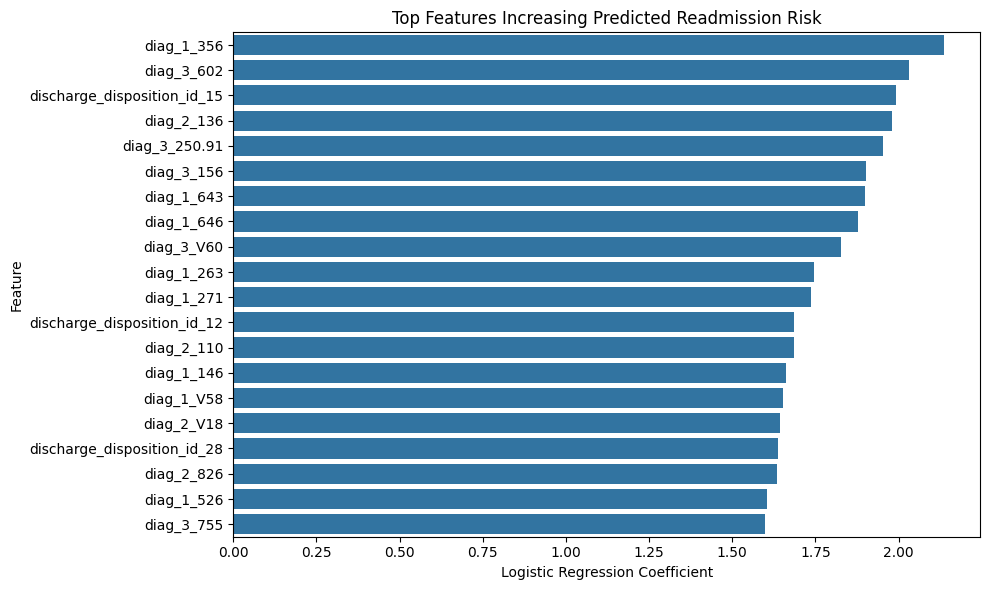

In [11]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_positive,
    x="coefficient",
    y="feature_clean"
)

plt.title("Top Features Increasing Predicted Readmission Risk")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Top Features Associated With Lower Readmission Risk

The following features have the most negative coefficients.

These features decrease the model's predicted probability of 30-day readmission.

In [12]:
top_negative = coef_df.sort_values(
    by="coefficient",
    ascending=True
).head(20)

top_negative[["feature_clean", "coefficient"]]

,feature_clean,coefficient
2295,discharge_disposition_id_11,-5.047269
1782,diag_3_537,-1.965138
1238,diag_2_807,-1.960304
1343,diag_2_999,-1.788511
1931,diag_3_736,-1.776450
976,diag_2_429,-1.771298
196,diag_1_304,-1.754652
1017,diag_2_481,-1.736749
862,diag_2_289,-1.705536
848,diag_2_275,-1.656270


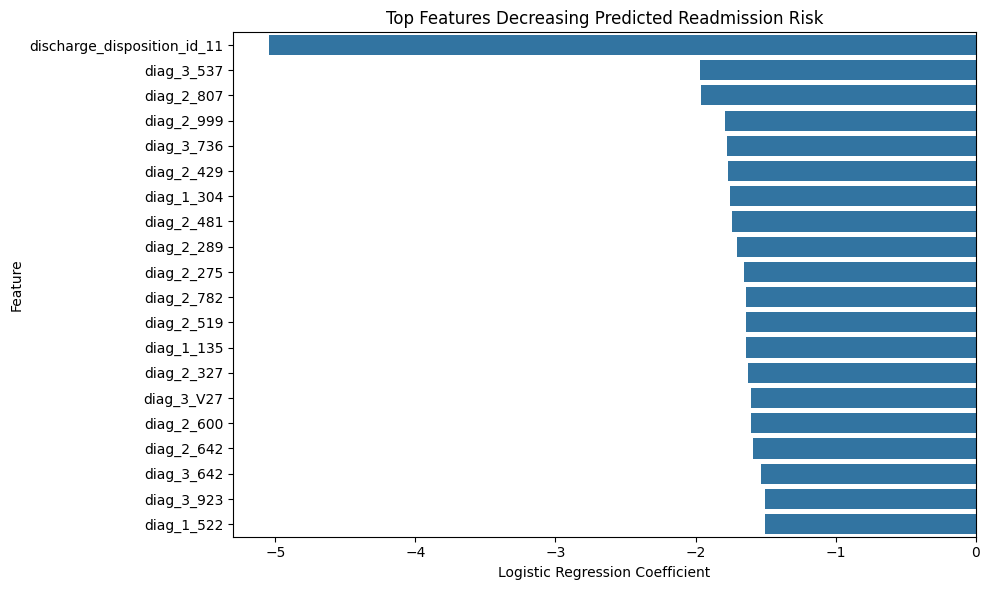

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_negative,
    x="coefficient",
    y="feature_clean"
)

plt.title("Top Features Decreasing Predicted Readmission Risk")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Note on Diagnosis Code Coefficients

Many of the strongest positive and negative coefficients come from diagnosis code categories.

These coefficients should be interpreted carefully because some diagnosis codes may appear only in a small number of records. A large coefficient does not always mean the feature is broadly important across the full patient population.

For this reason, numerical utilization features such as prior inpatient visits, emergency visits, number of medications, and number of diagnoses are more useful for high-level healthcare interpretation.

## Most Influential Features Overall

Some features strongly increase risk, while others strongly decrease risk.

Taking the absolute value of coefficients helps identify the most influential features overall.

In [14]:
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

top_overall = coef_df.sort_values(
    by="abs_coefficient",
    ascending=False
).head(25)

top_overall[["feature_clean", "coefficient", "abs_coefficient"]]

,feature_clean,coefficient,abs_coefficient
2295,discharge_disposition_id_11,-5.047269,5.047269
237,diag_1_356,2.138044,2.138044
1833,diag_3_602,2.032086,2.032086
2299,discharge_disposition_id_15,1.991064,1.991064
731,diag_2_136,1.981785,1.981785
1782,diag_3_537,-1.965138,1.965138
1238,diag_2_807,-1.960304,1.960304
1545,diag_3_250.91,1.953725,1.953725
1461,diag_3_156,1.902100,1.902100
466,diag_1_643,1.898132,1.898132


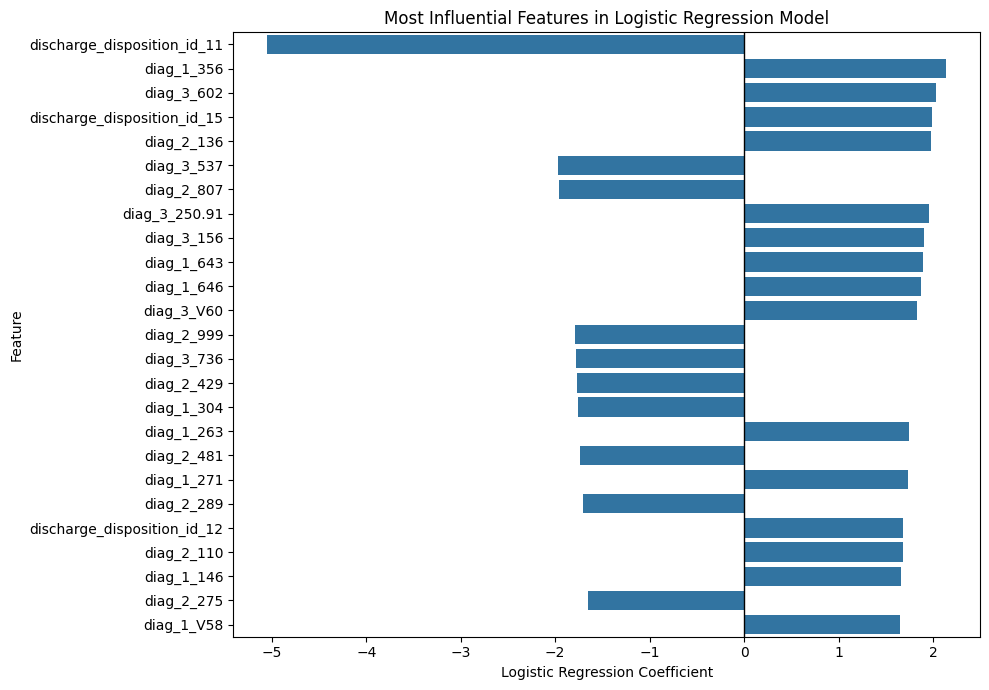

In [15]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_overall,
    x="coefficient",
    y="feature_clean"
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Most Influential Features in Logistic Regression Model")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Healthcare Interpretation of Key Numerical Features

Numerical features are especially useful because they often represent direct clinical or utilization-related patterns.

Examples include:

- `time_in_hospital`
- `num_lab_procedures`
- `num_procedures`
- `num_medications`
- `number_outpatient`
- `number_emergency`
- `number_inpatient`
- `number_diagnoses`

These features can help explain whether readmission risk is related to hospital utilization, treatment complexity, or previous healthcare visits.

In [16]:
numeric_feature_analysis = coef_df[
    coef_df["feature_clean"].isin([
        "time_in_hospital",
        "num_lab_procedures",
        "num_procedures",
        "num_medications",
        "number_outpatient",
        "number_emergency",
        "number_inpatient",
        "number_diagnoses"
    ])
].sort_values(by="coefficient", ascending=False)

numeric_feature_analysis[["feature_clean", "coefficient"]]

,feature_clean,coefficient
6,number_inpatient,0.342369
5,number_emergency,0.069725
3,num_medications,0.034095
7,number_diagnoses,0.031420
0,time_in_hospital,-0.003567
4,number_outpatient,-0.010868
1,num_lab_procedures,-0.011841
2,num_procedures,-0.014115


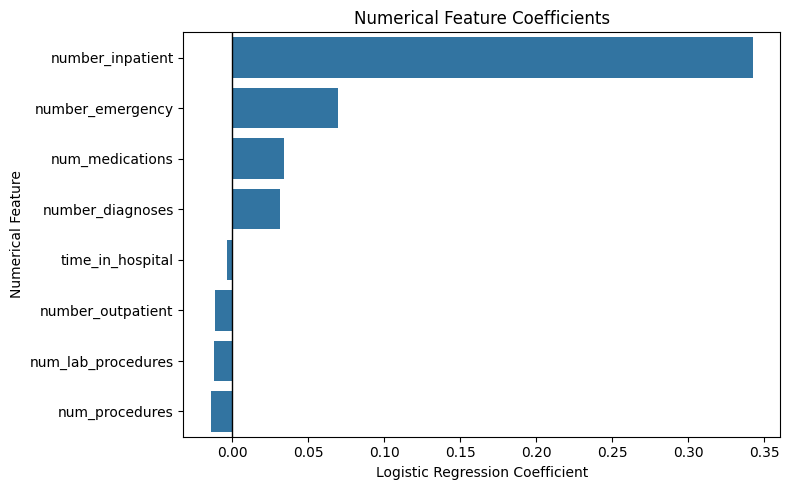

In [17]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=numeric_feature_analysis,
    x="coefficient",
    y="feature_clean"
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Numerical Feature Coefficients")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Numerical Feature")
plt.tight_layout()
plt.show()

## Interpretation of Numerical Features

The numerical feature coefficients show how patient utilization and hospital encounter characteristics relate to predicted readmission risk.

Features such as prior inpatient visits, emergency visits, number of medications, and number of diagnoses are especially important to review because they may reflect patient complexity and healthcare utilization.

A positive coefficient suggests that higher values of that feature are associated with increased predicted readmission risk, while a negative coefficient suggests lower predicted risk.

These findings are useful from a healthcare analytics perspective because they help identify patient groups who may benefit from stronger discharge planning, follow-up care, or care management support.

## Create Patient-Level Predicted Risk Scores

The model can also generate predicted probabilities for each patient.

These probabilities represent the model's estimated risk of 30-day readmission.

In [18]:
risk_scores = baseline_model.predict_proba(X)[:, 1]

df_risk = df.copy()
df_risk["predicted_readmission_risk"] = risk_scores

df_risk[["readmitted_30_days", "predicted_readmission_risk"]].head()

,readmitted_30_days,predicted_readmission_risk
0,0,0.074158
1,0,0.634403
2,0,0.139819
3,0,0.613894
4,0,0.530121


## Distribution of Predicted Readmission Risk

This plot shows how predicted risk scores are distributed across the patient population.

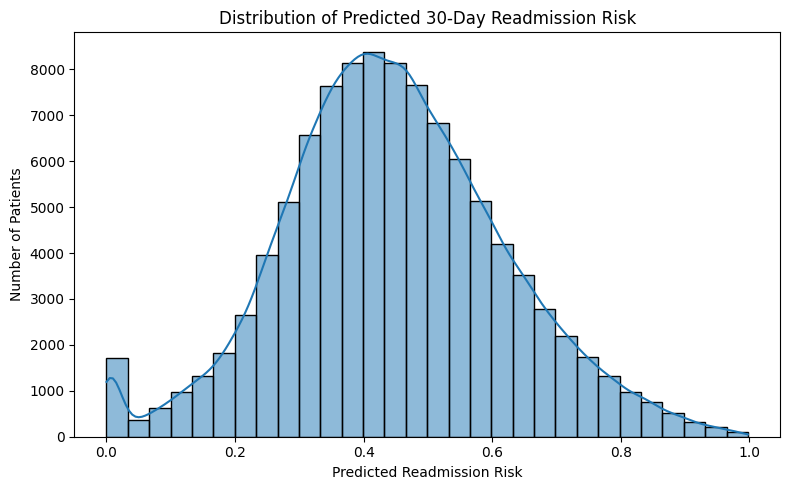

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_risk,
    x="predicted_readmission_risk",
    bins=30,
    kde=True
)

plt.title("Distribution of Predicted 30-Day Readmission Risk")
plt.xlabel("Predicted Readmission Risk")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

## Predicted Risk by Actual Readmission Outcome

This comparison shows whether patients who were actually readmitted within 30 days generally received higher predicted risk scores.

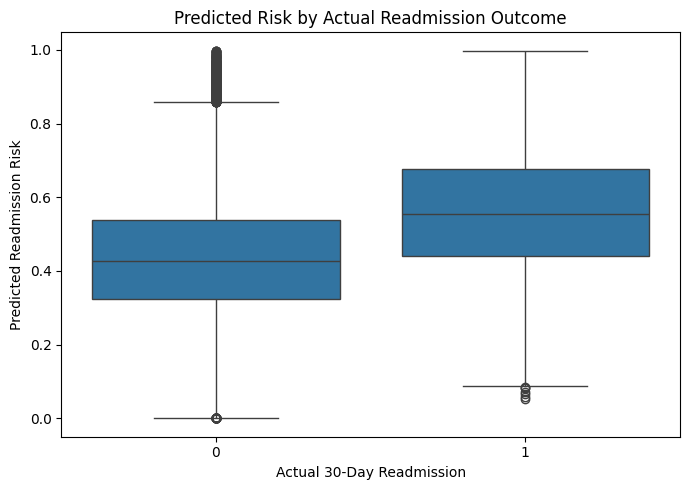

In [20]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_risk,
    x="readmitted_30_days",
    y="predicted_readmission_risk"
)

plt.title("Predicted Risk by Actual Readmission Outcome")
plt.xlabel("Actual 30-Day Readmission")
plt.ylabel("Predicted Readmission Risk")
plt.tight_layout()
plt.show()

## Create Risk Groups

For healthcare reporting, predicted probabilities can be grouped into low, medium, and high-risk categories.

This makes the model output easier to interpret for non-technical stakeholders.

### Risk Group Thresholds

The low-, medium-, and high-risk categories are created using simple probability thresholds for exploratory analysis.

These thresholds are not clinically validated and are intended only to demonstrate how predicted probabilities can be converted into actionable patient risk segments.

Future work could determine optimal thresholds using business requirements, cost-sensitive analysis, or recall-focused threshold tuning.

In [21]:
df_risk["risk_group"] = pd.cut(
    df_risk["predicted_readmission_risk"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

df_risk["risk_group"].value_counts()

risk_group
Medium Risk    64605
Low Risk       18722
High Risk      18439
Name: count, dtype: int64

## Actual Readmission Rate by Risk Group

This table checks whether higher predicted risk groups have higher actual 30-day readmission rates.

In [22]:
risk_group_summary = df_risk.groupby("risk_group").agg(
    patient_count=("readmitted_30_days", "count"),
    actual_readmission_rate=("readmitted_30_days", "mean"),
    avg_predicted_risk=("predicted_readmission_risk", "mean")
).reset_index()

risk_group_summary

,risk_group,patient_count,actual_readmission_rate,avg_predicted_risk
0,Low Risk,18722,0.026333,0.202778
1,Medium Risk,64605,0.098166,0.442493
2,High Risk,18439,0.245241,0.705777


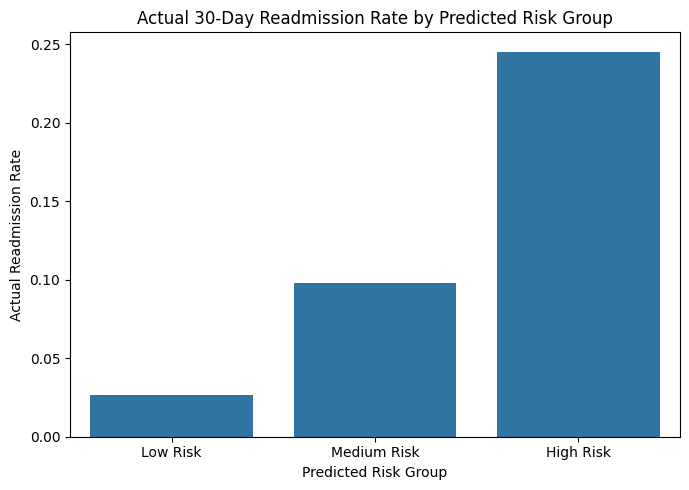

In [23]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=risk_group_summary,
    x="risk_group",
    y="actual_readmission_rate"
)

plt.title("Actual 30-Day Readmission Rate by Predicted Risk Group")
plt.xlabel("Predicted Risk Group")
plt.ylabel("Actual Readmission Rate")
plt.tight_layout()
plt.show()

The increasing readmission rate across risk groups suggests that the model is successfully ranking patients by risk level.

Patients classified as High Risk experience substantially higher observed readmission rates than patients in the Low Risk group, indicating that the predicted probabilities contain useful information for risk stratification.

## Save Risk Scores for Dashboarding

The dataset with predicted risk scores and risk groups is saved for later dashboarding.

This file can be used in Tableau to create visualizations for readmission risk patterns.

In [24]:
output_path = "../data/processed/readmission_risk_scores.csv"

df_risk.to_csv(output_path, index=False)

print(f"Risk score dataset saved to: {output_path}")

Risk score dataset saved to: ../data/processed/readmission_risk_scores.csv


## Summary

This notebook focused on interpreting the baseline Logistic Regression model.

Completed steps:

- Loaded the saved baseline model pipeline
- Extracted transformed feature names
- Extracted Logistic Regression coefficients
- Identified top features increasing predicted readmission risk
- Identified top features decreasing predicted readmission risk
- Reviewed important numerical healthcare features
- Generated patient-level predicted risk scores
- Created low, medium, and high-risk groups
- Compared actual readmission rates across risk groups
- Saved a risk score dataset for future Tableau dashboarding

The analysis shows how the model can move beyond prediction and support healthcare decision-making by identifying important risk factors and patient risk segments.